In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

In [34]:
# ── Load data ─────────────────────────────────────────────────────────────────
ROOT = '..'

grain = pd.read_csv(f'{ROOT}/processed data/price_2023_enso.csv')
harvest = pd.read_csv(f'{ROOT}/processed data/yield_ljungqvist_2025.csv')
fish = pd.read_csv(f'{ROOT}/processed data/fishprice_enso.csv')

#create a LatLon column for grouping
for df in [grain, harvest, fish]:
    df['LatLon'] = df['Latitude'].round(2).astype(str) + ',' + df['Longitude'].round(2).astype(str)
    

In [35]:
# ── Summarise to location level ───────────────────────────────────────────────

# Grain price: one row per Location
grain_locs = (
    grain.groupby('LatLon')
    .agg(n_years=('Year', 'nunique'),
         Latitude=('Latitude', 'first'),
         Longitude=('Longitude', 'first'),
         teleco=('teleco_PDSI_10', 'first'))
    .reset_index()
)

# Harvest: one row per Location (collapse across grain types)
harvest_locs = (
    harvest.groupby('LatLon')
    .agg(n_years=('Year', 'nunique'),
         Latitude=('Latitude', 'first'),
         Longitude=('Longitude', 'first'),
         teleco=('teleco_PDSI_10', 'first'))
    .reset_index()
)

# Fish price: one row per LocationSpecies; no teleco column → set to NaN
fish_locs = (
    fish.groupby('LatLon')
    .agg(n_years=('Year', 'nunique'),
         Latitude=('Latitude', 'first'),
         Longitude=('Longitude', 'first'),
         Species=('Species', 'first'),
         Location=('Location', 'first'))
    .reset_index()
)
# teleco not available for fish — mark all as unknown
fish_locs['teleco'] = np.nan

print('Grain locations:', len(grain_locs))
print('Harvest locations:', len(harvest_locs))
print('Fish series (LocationSpecies):', len(fish_locs))

Grain locations: 44
Harvest locations: 85
Fish series (LocationSpecies): 8


In [36]:
# ── Plot helper ───────────────────────────────────────────────────────────────
COL_TELECO    = '#d62728'  # red  – teleconnected
COL_NONTELECO = '#1f77b4'  # blue – not teleconnected
COL_UNKNOWN   = 'black'  # grey – no teleco info

SIZE_SCALE = 0.8  # dot area = n_years * SIZE_SCALE

def plot_locs(ax, locs, jitter=0.0):
    """Scatter locations; colour by teleco status, size by n_years."""
    rng = np.random.default_rng(0)
    for _, row in locs.iterrows():
        t = row['teleco']
        if np.isnan(float(t)) if not isinstance(t, float) else np.isnan(t):
            col = COL_UNKNOWN
        elif t == 1:
            col = COL_TELECO
        else:
            col = COL_NONTELECO
        x = row['Longitude'] + rng.uniform(-jitter, jitter)
        y = row['Latitude']  + rng.uniform(-jitter, jitter)
        ax.scatter(x, y,
                   s=row['n_years'] * SIZE_SCALE,
                   color=col, edgecolors='white', linewidths=0.5,
                   alpha=0.85, transform=ccrs.PlateCarree(), zorder=3)


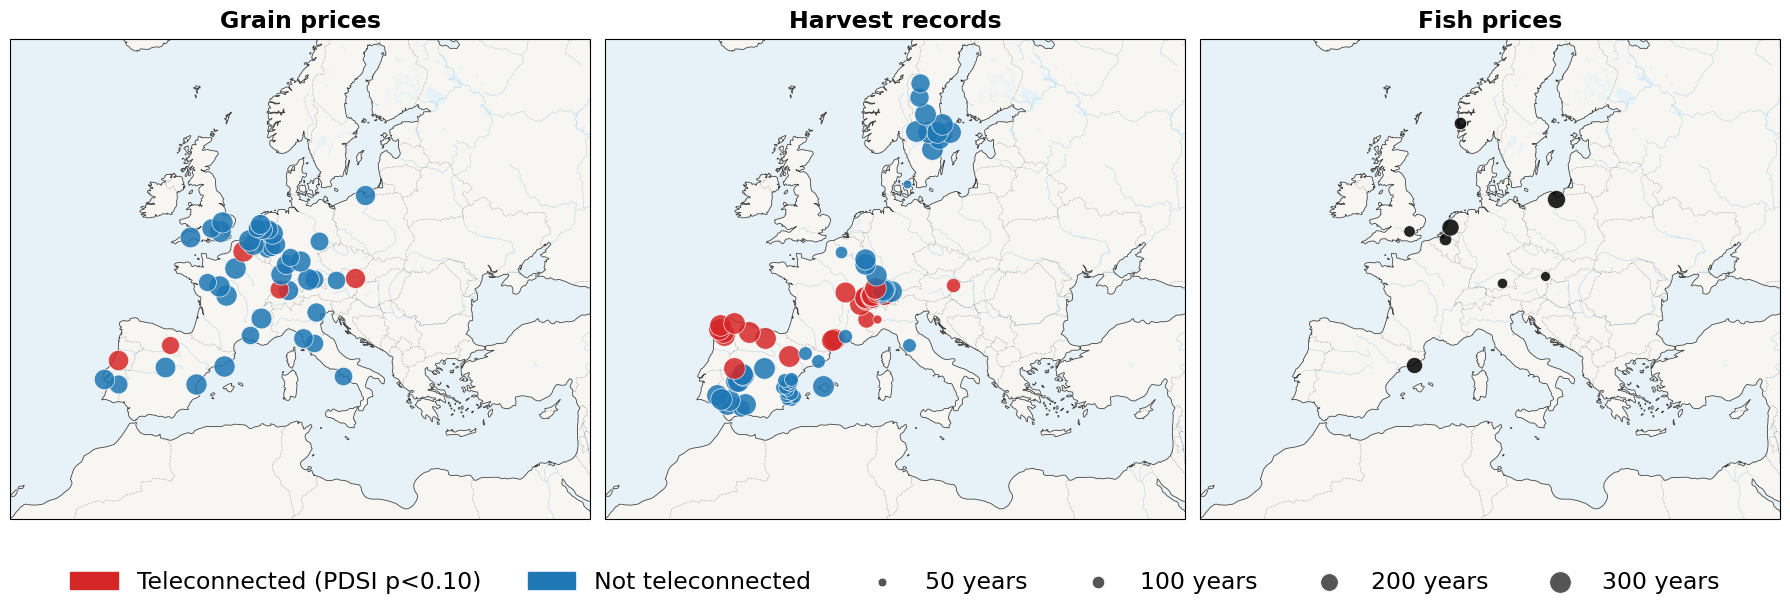

Saved map_data_coverage.pdf


In [37]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Projection (Europe-optimized) ─────────────────────────────────────────────
proj = ccrs.LambertConformal(
    central_longitude=10,
    central_latitude=50,
    standard_parallels=(35, 65)
)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={'projection': proj}
)

titles   = ['Grain prices', 'Harvest records', 'Fish prices']
datasets = [grain_locs, harvest_locs, fish_locs]

for ax, title, locs in zip(axes, titles, datasets):
    
    # Europe extent (in PlateCarree coords)
    ax.set_extent([-15, 35, 30, 65], crs=ccrs.PlateCarree())
    
    # ── Base map styling ─────────────────────────────────────────
    ax.add_feature(cfeature.LAND, facecolor='#f7f6f2', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f2f8', zorder=0)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='#444444', zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':', color='#666666', zorder=1)
    
    # Optional: lakes & rivers for aesthetics
    ax.add_feature(cfeature.LAKES, facecolor='#e6f2f8', edgecolor='none', zorder=0)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, color='#a6cbe3', zorder=0)
    
    # Clean look: remove gridlines unless needed
    # gl = ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.3)
    
    ax.set_title(title, fontsize=17, fontweight='bold', pad=8)
    
    # IMPORTANT: keep data in PlateCarree
    plot_locs(ax, locs, jitter=0.15)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COL_TELECO,    label='Teleconnected (PDSI p<0.10)'),
    mpatches.Patch(color=COL_NONTELECO, label='Not teleconnected')
]

for n in [50, 100, 200, 300]:
    legend_handles.append(
        plt.scatter([], [], s=n * SIZE_SCALE, color='#555555',
                    edgecolors='white', linewidths=0.5,
                    label=f'{n} years')
    )

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=7,
    fontsize=17,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    '../analysis/output/figures/appendix/map_data_coverage.pdf',
    bbox_inches='tight',
    dpi=300
)

plt.show()
print('Saved map_data_coverage.pdf')